# Bank Marketing — Logistic Regression Classifier
## Financial Assistant Project | Classification Model

This notebook trains a **Logistic Regression Classifier** on the UCI Bank Marketing dataset.  
The goal is to predict whether a customer will **subscribe to a term deposit** (yes/no) based on demographic and interaction features.

### Steps covered:
1. Load dataset  
2. Exploratory Data Analysis (EDA)  
3. Preprocessing — encode categoricals, normalize numerics, train/test split  
4. Model training  
5. Evaluation — Accuracy, Precision, Recall, F1, Confusion Matrix  
6. Save model artifacts  
7. Inference function for SageMaker


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import joblib
import os

print("All libraries imported successfully")

All libraries imported successfully


## 2. Load Dataset

In [2]:
import pandas as pd
import requests
import zipfile
from io import BytesIO

url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

try:
    response = requests.get(url)
    response.raise_for_status()

    # Outer ZIP
    outer_zip = zipfile.ZipFile(BytesIO(response.content))

    # Inner ZIP
    inner_zip_bytes = outer_zip.read("bank-additional.zip")
    inner_zip = zipfile.ZipFile(BytesIO(inner_zip_bytes))

    print("Inner archive contents:")
    print(inner_zip.namelist())

    df = pd.read_csv(
        inner_zip.open("bank-additional/bank-additional-full.csv"),
        sep=";"
    )

    print(f"Downloaded from UCI. Shape: {df.shape}")

except Exception as e:
    print(f"Download failed ({e}), loading locally...")
    df = pd.read_csv("bank-additional-full.csv", sep=";")
    print(f"Loaded locally. Shape: {df.shape}")

df.head()

Inner archive contents:
['bank-additional/', 'bank-additional/.DS_Store', '__MACOSX/', '__MACOSX/bank-additional/', '__MACOSX/bank-additional/._.DS_Store', 'bank-additional/.Rhistory', 'bank-additional/bank-additional-full.csv', 'bank-additional/bank-additional-names.txt', 'bank-additional/bank-additional.csv', '__MACOSX/._bank-additional']
Downloaded from UCI. Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Exploratory Data Analysis

In [3]:
print("=== Basic Statistics ===")
display(df.describe())
print(f"\nMissing values: {df.isnull().sum().sum()}")

=== Basic Statistics ===


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



Missing values: 0


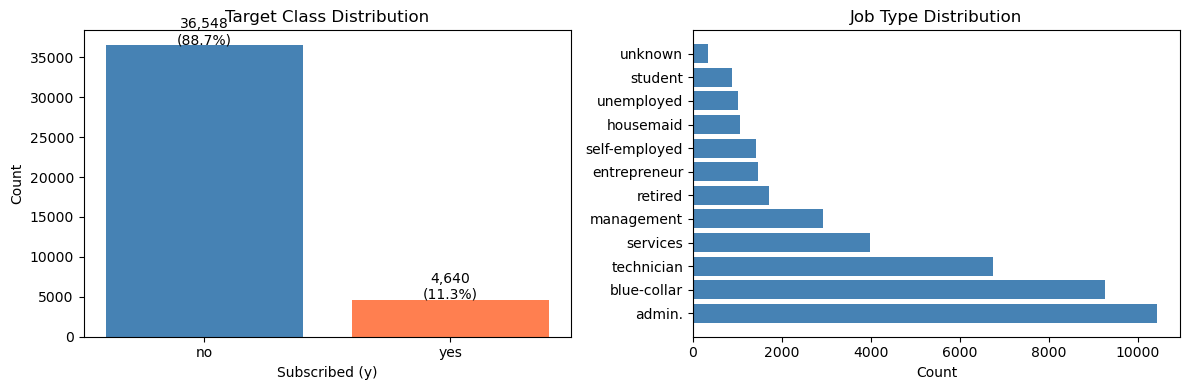

Note: Dataset is imbalanced — more 'no' than 'yes'. We handle this with class_weight=balanced.


In [4]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['y'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Target Class Distribution')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

# Job distribution
job_counts = df['job'].value_counts()
axes[1].barh(job_counts.index, job_counts.values, color='steelblue')
axes[1].set_title('Job Type Distribution')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('target_class_distribution.png', dpi=150)
plt.show()
print("Note: Dataset is imbalanced — more 'no' than 'yes'. We handle this with class_weight=balanced.")

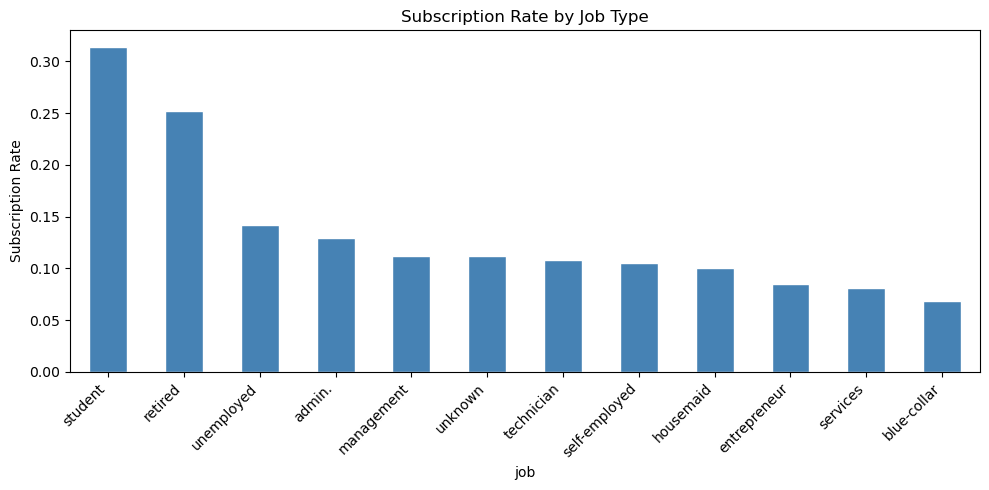

In [5]:
# Subscription rate by job type
sub_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sub_rate.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Subscription Rate by Job Type')
plt.ylabel('Subscription Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [6]:
# Step 1: Encode target column (yes → 1, no → 0)
df['y'] = (df['y'] == 'yes').astype(int)
print(f"Target encoded: 0={( df['y']==0).sum():,} | 1={(df['y']==1).sum():,}")

Target encoded: 0=36,548 | 1=4,640


In [7]:
# Step 2: Encode all categorical columns with LabelEncoder
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}\n")

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"  {col}: {list(le.classes_[:4])} → {list(range(4))} ...")

print("\nAll categorical columns encoded.")

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

  job: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid'] → [0, 1, 2, 3] ...
  marital: ['divorced', 'married', 'single', 'unknown'] → [0, 1, 2, 3] ...
  education: ['basic.4y', 'basic.6y', 'basic.9y', 'high.school'] → [0, 1, 2, 3] ...
  default: ['no', 'unknown', 'yes'] → [0, 1, 2, 3] ...
  housing: ['no', 'unknown', 'yes'] → [0, 1, 2, 3] ...
  loan: ['no', 'unknown', 'yes'] → [0, 1, 2, 3] ...
  contact: ['cellular', 'telephone'] → [0, 1, 2, 3] ...
  month: ['apr', 'aug', 'dec', 'jul'] → [0, 1, 2, 3] ...
  day_of_week: ['fri', 'mon', 'thu', 'tue'] → [0, 1, 2, 3] ...
  poutcome: ['failure', 'nonexistent', 'success'] → [0, 1, 2, 3] ...

All categorical columns encoded.


In [8]:
# Step 3: Split features and target
X = df.drop('y', axis=1)
y = df['y']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

Features shape : (41188, 20)
Target shape   : (41188,)


In [9]:
# Step 4: Train / test split with stratify to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nClass balance in train: {y_train.value_counts().to_dict()}")
print(f"Class balance in test : {y_test.value_counts().to_dict()}")

Training samples : 32950
Test samples     : 8238

Class balance in train: {0: 29238, 1: 3712}
Class balance in test : {0: 7310, 1: 928}


In [10]:
# Step 5: Normalize numeric features
# fit_transform on train, transform only on test (no data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Features normalized.")

Features normalized.


## 5. Train Model

In [11]:
model = LogisticRegression(
    max_iter=1000,           # enough iterations to converge
    random_state=42,
    class_weight='balanced'  # compensates for class imbalance
)

print("Training Logistic Regression classifier...")
model.fit(X_train_scaled, y_train)
print("Training complete.")

Training Logistic Regression classifier...
Training complete.


## 6. Evaluate Model

In [12]:
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("=" * 40)
print("       Evaluation Metrics")
print("=" * 40)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 40)
print()
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

       Evaluation Metrics
  Accuracy  : 0.8569
  Precision : 0.4347
  Recall    : 0.8998
  F1 Score  : 0.5862

              precision    recall  f1-score   support

          No       0.99      0.85      0.91      7310
         Yes       0.43      0.90      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.88      0.75      8238
weighted avg       0.92      0.86      0.88      8238



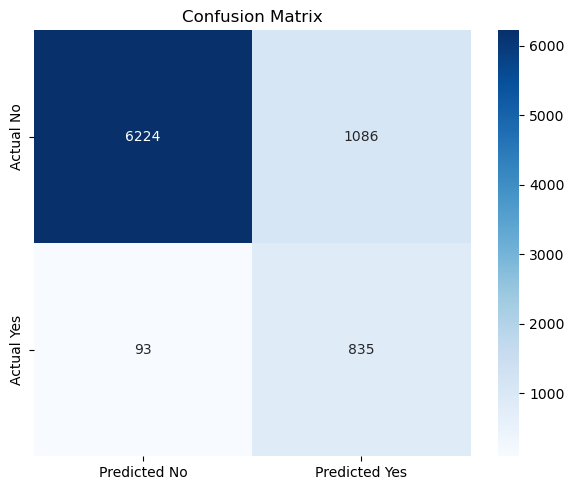

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 7. Save Model Artifacts

In [14]:
os.makedirs('model_artifacts', exist_ok=True)
joblib.dump(model,             'model_artifacts/logistic_classifier.joblib')
joblib.dump(scaler,            'model_artifacts/scaler_classification.joblib')
joblib.dump(encoders,          'model_artifacts/label_encoders.joblib')
joblib.dump(list(X.columns),   'model_artifacts/feature_columns.joblib')

print("Saved:")
print("  model_artifacts/logistic_classifier.joblib")
print("  model_artifacts/scaler_classification.joblib")
print("  model_artifacts/label_encoders.joblib")
print("  model_artifacts/feature_columns.joblib")

Saved:
  model_artifacts/logistic_classifier.joblib
  model_artifacts/scaler_classification.joblib
  model_artifacts/label_encoders.joblib
  model_artifacts/feature_columns.joblib


## 8. Inference Function (SageMaker)
This function is what the SageMaker endpoint will call when it receives a prediction request.


In [15]:
def predict_subscription(features: dict) -> dict:
    """
    Input : dict with bank marketing feature columns
    Output: { prediction: 0/1, probability: float, label: 'yes'/'no' }
    """
    m  = joblib.load('model_artifacts/logistic_classifier.joblib')
    s  = joblib.load('model_artifacts/scaler_classification.joblib')
    e  = joblib.load('model_artifacts/label_encoders.joblib')
    cols = joblib.load('model_artifacts/feature_columns.joblib')

    input_df = pd.DataFrame([features])
    for col, le in e.items():
        if col in input_df.columns:
            input_df[col] = le.transform(input_df[col])

    input_df = input_df[cols]
    scaled   = s.transform(input_df)
    pred     = int(m.predict(scaled)[0])
    prob     = round(float(m.predict_proba(scaled)[0][1]), 4)
    return {'prediction': pred, 'probability': prob,
            'label': 'yes' if pred == 1 else 'no'}

# Test the inference function
sample = {
    'age': 35, 'job': 'management', 'marital': 'married',
    'education': 'university.degree', 'default': 'no',
    'housing': 'yes', 'loan': 'no', 'contact': 'cellular',
    'month': 'may', 'day_of_week': 'mon', 'duration': 300,
    'campaign': 2, 'pdays': 999, 'previous': 0,
    'poutcome': 'nonexistent', 'emp.var.rate': -1.8,
    'cons.price.idx': 92.893, 'cons.conf.idx': -46.2,
    'euribor3m': 1.299, 'nr.employed': 5099.1
}
print(predict_subscription(sample))

{'prediction': 0, 'probability': 0.4213, 'label': 'no'}
